# ISP Tutorial Notebook 01

这份 notebook 的目标不是只把变量名抄一遍，而是把 `policy/ISP` 里**训练一条 ISP policy 的完整流程**串起来：

- 训练入口是怎么被 Hydra 配起来的
- 原始 UniVTAC `hdf5` demo 怎样变成训练样本
- `SequenceSampler` 怎样切时间窗
- `ws_center` 和 normalizer 在做什么
- ISP 的观测编码器怎样把图像和机器人状态变成旋转相关特征
- `SO2` 和 `SO3` 在代码里到底哪里分叉
- diffusion loss、EMA、validation、checkpoint 的主线是什么

Notebook 的风格会是：

- 先用 `print` 讲清主流程
- 再用 SVG/HTML 做轻量可视化
- 有些比较重的真实数据/模型 cell 默认关闭，你可以按需打开

对应代码仓库根目录：`/home/zhenya/kenny/visuotact/UniVTAC`。

In [1]:
from pathlib import Path
import sys
import json
import yaml
import textwrap
import importlib
import inspect
import base64
import math

import numpy as np

np.set_printoptions(precision=3, suppress=True)

REPO_ROOT = Path('/home/zhenya/kenny/visuotact/UniVTAC').resolve()
ISP_ROOT = REPO_ROOT / 'policy' / 'ISP'

if str(ISP_ROOT) not in sys.path:
    sys.path.insert(0, str(ISP_ROOT))

try:
    from IPython.display import display, Markdown, SVG, HTML
    HAVE_IPYTHON_DISPLAY = True
except Exception:
    HAVE_IPYTHON_DISPLAY = False
    display = print
    Markdown = lambda x: x
    SVG = lambda x: x
    HTML = lambda x: x


def print_title(title):
    print()
    print('=' * 96)
    print(title)
    print('=' * 96)


def print_kv(key, value):
    print(f'- {key}: {value}')


def print_table(headers, rows):
    widths = [len(str(h)) for h in headers]
    for row in rows:
        widths = [max(w, len(str(cell))) for w, cell in zip(widths, row)]
    fmt = ' | '.join(f'{{:<{w}}}' for w in widths)
    print(fmt.format(*headers))
    print('-+-'.join('-' * w for w in widths))
    for row in rows:
        print(fmt.format(*row))


def read_yaml(path):
    with open(path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def maybe_display_svg(svg_text):
    if HAVE_IPYTHON_DISPLAY:
        display(SVG(svg_text))
    else:
        print(svg_text)


def maybe_display_html(html_text):
    if HAVE_IPYTHON_DISPLAY:
        display(HTML(html_text))
    else:
        print(html_text)


def import_from_path(path_str):
    module_name, attr_name = path_str.rsplit('.', 1)
    module = importlib.import_module(module_name)
    return getattr(module, attr_name)


def short_path(path):
    try:
        return str(Path(path).resolve().relative_to(REPO_ROOT))
    except Exception:
        return str(path)


print_title('Notebook 初始化')
print_kv('REPO_ROOT', REPO_ROOT)
print_kv('ISP_ROOT', ISP_ROOT)
print_kv('HAVE_IPYTHON_DISPLAY', HAVE_IPYTHON_DISPLAY)
print('sys.path[0] =', sys.path[0])


Notebook 初始化
- REPO_ROOT: /home/zhenya/kenny/visuotact/UniVTAC
- ISP_ROOT: /home/zhenya/kenny/visuotact/UniVTAC/policy/ISP
- HAVE_IPYTHON_DISPLAY: True
sys.path[0] = /home/zhenya/kenny/visuotact/UniVTAC/policy/ISP


## 1. 从训练入口开始：谁实例化谁

这个仓库里 `policy/ISP/train.py` 很薄。它主要做 3 件事：

1. 让 Hydra 读取 config
2. 检查 `task_name` 合法
3. 根据 config 里的 `_target_` 实例化 `TrainISPWorkspace` 并执行 `workspace.run()`

所以真正要理解训练，核心不是盯着 `train.py` 本身，而是盯着：

- `isp/config/*.yaml`
- `isp/workspace/train_isp_workspace.py`
- `isp/dataset/*.py`
- `isp/policy/*.py`
- `isp/model/equi/*.py`


In [2]:
train_py = ISP_ROOT / 'train.py'
cfg_so2 = read_yaml(ISP_ROOT / 'isp/config/train_isp_so2.yaml')
cfg_so3 = read_yaml(ISP_ROOT / 'isp/config/train_isp_so3.yaml')
task_cfg = read_yaml(ISP_ROOT / 'isp/config/task/univtac.yaml')

print_title('训练入口与配置摘要')
print('train.py 主逻辑: train.py -> hydra.main(...) -> workspace = cls(cfg) -> workspace.run()')
print_kv('SO2 workspace target', cfg_so2['_target_'])
print_kv('SO3 workspace target', cfg_so3['_target_'])
print_kv('task config file', short_path(ISP_ROOT / 'isp/config/task/univtac.yaml'))

rows = [
    ('name', cfg_so2['name'], cfg_so3['name']),
    ('dataset class', cfg_so2['dataset'], cfg_so3['dataset']),
    ('policy class', cfg_so2['policy']['_target_'], cfg_so3['policy']['_target_']),
    ('horizon', cfg_so2['horizon'], cfg_so3['horizon']),
    ('n_obs_steps', cfg_so2['n_obs_steps'], cfg_so3['n_obs_steps']),
    ('n_action_steps', cfg_so2['n_action_steps'], cfg_so3['n_action_steps']),
    ('num_epochs', cfg_so2['training']['num_epochs'], cfg_so3['training']['num_epochs']),
    ('lmax', cfg_so2['policy']['lmax'], cfg_so3['policy']['lmax']),
    ('encoder', cfg_so2['policy']['encoder'], cfg_so3['policy']['encoder']),
]
print_table(['field', 'SO2', 'SO3'], rows)

print()
print('task shape_meta:')
print(json.dumps(task_cfg['shape_meta'], indent=2, ensure_ascii=False))

print()
print('动作 10 维的语义不是 10 个无关标量，而是:')
print('  action = [位置3, 旋转6D, gripper1]')
print('  也就是 [x, y, z, r6d_1..r6d_6, g]')

print()
print('注意: 这里我们直接用 yaml.safe_load 读原始 YAML，所以像 ${shape_meta} 这样的 Hydra 插值不会在 notebook 里自动展开。')
print('真正需要用到 shape_meta 时，我们直接用 task/univtac.yaml 里的定义。')


训练入口与配置摘要
train.py 主逻辑: train.py -> hydra.main(...) -> workspace = cls(cfg) -> workspace.run()
- SO2 workspace target: isp.workspace.train_isp_workspace.TrainISPWorkspace
- SO3 workspace target: isp.workspace.train_isp_workspace.TrainISPWorkspace
- task config file: policy/ISP/isp/config/task/univtac.yaml
field          | SO2                                                                              | SO3                                                                             
---------------+----------------------------------------------------------------------------------+---------------------------------------------------------------------------------
name           | isp_so2                                                                          | isp_so3                                                                         
dataset class  | isp.dataset.univtac_replay_image_so2_sym_dataset.UniVTACReplayImageSO2SymDataset | isp.dataset.univtac_replay_image_so3_sym_dataset.


一张图看完整训练主线


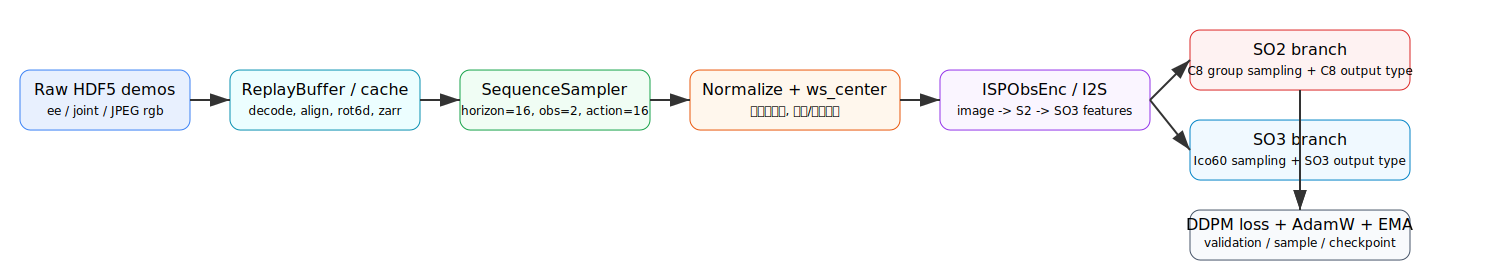

In [10]:
print_title('一张图看完整训练主线')

svg = '''
<svg width='1500' height='280' xmlns='http://www.w3.org/2000/svg'>
  <defs>
    <marker id='arrow' markerWidth='10' markerHeight='10' refX='9' refY='3' orient='auto'>
      <path d='M0,0 L0,6 L9,3 z' fill='#333' />
    </marker>
  </defs>
  <rect x='20'  y='70' width='170' height='60' rx='10' fill='#e8f0fe' stroke='#3b82f6' />
  <text x='105' y='95' text-anchor='middle' font-size='16'>Raw HDF5 demos</text>
  <text x='105' y='115' text-anchor='middle' font-size='12'>ee / joint / JPEG rgb</text>

  <rect x='230' y='70' width='190' height='60' rx='10' fill='#ecfeff' stroke='#0891b2' />
  <text x='325' y='95' text-anchor='middle' font-size='16'>ReplayBuffer / cache</text>
  <text x='325' y='115' text-anchor='middle' font-size='12'>decode, align, rot6d, zarr</text>

  <rect x='460' y='70' width='190' height='60' rx='10' fill='#f0fdf4' stroke='#16a34a' />
  <text x='555' y='95' text-anchor='middle' font-size='16'>SequenceSampler</text>
  <text x='555' y='115' text-anchor='middle' font-size='12'>horizon=16, obs=2, action=16</text>

  <rect x='690' y='70' width='210' height='60' rx='10' fill='#fff7ed' stroke='#ea580c' />
  <text x='795' y='95' text-anchor='middle' font-size='16'>Normalize + ws_center</text>
  <text x='795' y='115' text-anchor='middle' font-size='12'>位置减中心, 图像/位置缩放</text>

  <rect x='940' y='70' width='210' height='60' rx='10' fill='#faf5ff' stroke='#9333ea' />
  <text x='1045' y='95' text-anchor='middle' font-size='16'>ISPObsEnc / I2S</text>
  <text x='1045' y='115' text-anchor='middle' font-size='12'>image -> S2 -> SO3 features</text>

  <rect x='1190' y='30' width='220' height='60' rx='10' fill='#fef2f2' stroke='#dc2626' />
  <text x='1300' y='55' text-anchor='middle' font-size='16'>SO2 branch</text>
  <text x='1300' y='75' text-anchor='middle' font-size='12'>C8 group sampling + C8 output type</text>

  <rect x='1190' y='120' width='220' height='60' rx='10' fill='#f0f9ff' stroke='#0284c7' />
  <text x='1300' y='145' text-anchor='middle' font-size='16'>SO3 branch</text>
  <text x='1300' y='165' text-anchor='middle' font-size='12'>Ico60 sampling + SO3 output type</text>

  <rect x='1190' y='210' width='220' height='50' rx='10' fill='#f8fafc' stroke='#475569' />
  <text x='1300' y='230' text-anchor='middle' font-size='16'>DDPM loss + AdamW + EMA</text>
  <text x='1300' y='247' text-anchor='middle' font-size='12'>validation / sample / checkpoint</text>

  <line x1='190' y1='100' x2='230' y2='100' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='420' y1='100' x2='460' y2='100' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='650' y1='100' x2='690' y2='100' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='900' y1='100' x2='940' y2='100' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='1150' y1='100' x2='1190' y2='60' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='1150' y1='100' x2='1190' y2='150' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='1300' y1='90'  x2='1300' y2='210' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
  <line x1='1300' y1='180' x2='1300' y2='210' stroke='#333' stroke-width='2' marker-end='url(#arrow)' />
</svg>
'''

maybe_display_svg(svg)

## 2. 数据集准备：原始 demo 怎样变成训练样本

这一步的核心文件是：

- `isp/dataset/univtac_replay_image_dataset.py`
- `isp/dataset/univtac_replay_image_so2_sym_dataset.py`
- `isp/dataset/univtac_replay_image_so3_sym_dataset.py`
- `isp/common/sampler.py`

你可以先牢牢记住 3 个事实：

1. **SO2 和 SO3 在读取 HDF5 原始文件时几乎没有区别**
2. 区别主要发生在 normalizer 的对称化方式，以及后面的群采样/输出层
3. dataset 输出给模型的不是单帧，而是 `obs 前 2 步 + action 全 16 步` 的时间窗


In [5]:
print_title('搜索可能存在的 UniVTAC 数据集根目录')

default_dataset_root = Path(cfg_so2['dataset_root']).expanduser()
candidate_roots = [
    default_dataset_root,
    REPO_ROOT / 'data' / 'UniVTAC',
    REPO_ROOT / 'data',
]


def find_hdf5_files(root):
    if not root.exists():
        return []
    flat = sorted(root.glob('*/hdf5/*.hdf5'))
    legacy = sorted(root.glob('*/*/hdf5/*.hdf5'))
    return flat + legacy


def infer_task_name(h5_path):
    if h5_path.parent.name != 'hdf5':
        return None
    parent = h5_path.parent.parent
    if parent.name in {'clean', 'train', 'val', 'test'}:
        return parent.parent.name
    return parent.name


all_found = []
for root in candidate_roots:
    files = find_hdf5_files(root)
    print_kv(short_path(root), f'exists={root.exists()}  hdf5_files={len(files)}')
    all_found.extend(files)

AUTO_EPISODE_PATH = all_found[0] if all_found else None
AUTO_TASK_NAME = infer_task_name(AUTO_EPISODE_PATH) if AUTO_EPISODE_PATH else None
AUTO_DATASET_ROOT = None
if AUTO_EPISODE_PATH is not None:
    if AUTO_EPISODE_PATH.parent.parent.name in {'clean', 'train', 'val', 'test'}:
        AUTO_DATASET_ROOT = AUTO_EPISODE_PATH.parent.parent.parent.parent
    else:
        AUTO_DATASET_ROOT = AUTO_EPISODE_PATH.parent.parent.parent

print()
print('期望的数据布局大致是:')
print(textwrap.dedent('''
    data/<EXPERIMENT_NAME>/<task_name>/hdf5/*.hdf5
    或者
    <dataset_root>/<task_name>/hdf5/*.hdf5
    或者旧布局
    <dataset_root>/<task_name>/<split>/hdf5/*.hdf5
''').strip())

if AUTO_EPISODE_PATH is None:
    print()
    print('当前没有自动找到 hdf5 demo。后面的真实数据 cell 会跳过，但教学图和流程解释仍然可以看。')
else:
    print()
    print_kv('AUTO_EPISODE_PATH', AUTO_EPISODE_PATH)
    print_kv('AUTO_TASK_NAME', AUTO_TASK_NAME)
    print_kv('AUTO_DATASET_ROOT', AUTO_DATASET_ROOT)


搜索可能存在的 UniVTAC 数据集根目录
- /mnt/pfs/rmgf7p/tanzl/Kenny/code/visuotactile/data/UniVTAC: exists=False  hdf5_files=0
- /home/zhenya/kenny/visuotact/UniVTAC/data/UniVTAC: exists=False  hdf5_files=0
- /home/zhenya/kenny/visuotact/UniVTAC/data: exists=True  hdf5_files=800

期望的数据布局大致是:
data/<EXPERIMENT_NAME>/<task_name>/hdf5/*.hdf5
或者
<dataset_root>/<task_name>/hdf5/*.hdf5
或者旧布局
<dataset_root>/<task_name>/<split>/hdf5/*.hdf5

- AUTO_EPISODE_PATH: /home/zhenya/kenny/visuotact/UniVTAC/data/MIDFOV_EXPERIMENT/grasp_classify/hdf5/0.hdf5
- AUTO_TASK_NAME: grasp_classify
- AUTO_DATASET_ROOT: /home/zhenya/kenny/visuotact/UniVTAC/data/MIDFOV_EXPERIMENT



检查一个真实 HDF5 episode 的结构，并复现 repo 的解析逻辑
- episode file: 0.hdf5
- task: grasp_classify
actor/
  green_pad: shape=(44, 7), dtype=float32
  orange_pad: shape=(44, 7), dtype=float32
  plain_prism: shape=(44, 7), dtype=float32
  rough_prism: shape=(44, 7), dtype=float32
atom/
  id: shape=(44,), dtype=int64
  tag: shape=(44,), dtype=|S5
embodiment/
  ee: shape=(44, 7), dtype=float32
  joint: shape=(44, 9), dtype=float32
observation/
  head/
    rgb: shape=(44,), dtype=|S38334
  wrist/
    rgb: shape=(44,), dtype=|S30030
step: shape=(44,), dtype=int64
tactile/
  left_tactile/
    depth: shape=(44, 240, 320), dtype=float32
    marker: shape=(44, 2, 64, 2), dtype=float32
    pose: shape=(44, 7), dtype=float32
    rgb: shape=(44,), dtype=|S10700
    rgb_marker: shape=(44,), dtype=|S23687
  right_tactile/
    depth: shape=(44, 240, 320), dtype=float32
    marker: shape=(44, 2, 64, 2), dtype=float32
    pose: shape=(44, 7), dtype=float32
    rgb: shape=(44,), dtype=|S10552
    rgb_marker: shape=(4


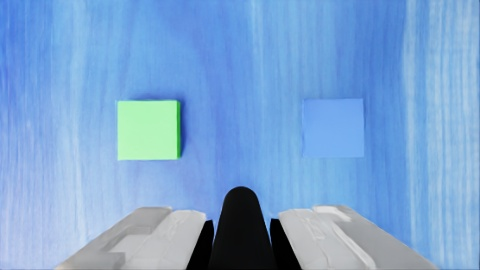


按照 repo 的 _episode_to_arrays() 解析后，各个数组的 shape 是:
key                      | shape           | dtype   | min           | max         
-------------------------+-----------------+---------+---------------+-------------

调用 repo 的 _episode_to_arrays() 失败，通常是依赖或环境问题:
TypeError unsupported format string passed to tuple.__format__


In [6]:
print_title('检查一个真实 HDF5 episode 的结构，并复现 repo 的解析逻辑')

if AUTO_EPISODE_PATH is None:
    print('跳过: 当前没有自动找到 hdf5 demo 文件。')
else:
    import h5py

    def print_h5_tree(obj, prefix=''):
        for key in obj.keys():
            item = obj[key]
            if isinstance(item, h5py.Dataset):
                print(f'{prefix}{key}: shape={item.shape}, dtype={item.dtype}')
            else:
                print(f'{prefix}{key}/')
                print_h5_tree(item, prefix + '  ')

    with h5py.File(AUTO_EPISODE_PATH, 'r') as f:
        print_kv('episode file', AUTO_EPISODE_PATH.name)
        print_kv('task', AUTO_TASK_NAME)
        print_h5_tree(f)

        if 'embodiment/ee' in f:
            ee = f['embodiment/ee'][:3]
            print()
            print('前 3 行 embodiment/ee (pos + quat[wxyz]):')
            print(ee)

        if 'embodiment/joint' in f:
            joint = f['embodiment/joint'][:3]
            print()
            print('前 3 行 embodiment/joint:')
            print(joint)

        rgb_source = None
        for candidate in ['observation/wrist/rgb', 'observation/head/rgb']:
            if candidate in f:
                rgb_source = candidate
                break

        if rgb_source is not None:
            print()
            print_kv('RGB source chosen for display', rgb_source)
            try:
                from isp.dataset.univtac_replay_image_dataset import _decode_jpeg_to_rgb
                image = _decode_jpeg_to_rgb(f[rgb_source][0])
                print('成功解码第一帧 RGB:', image.shape, image.dtype)
                try:
                    import cv2
                    ok, png = cv2.imencode('.png', cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
                    if ok:
                        b64 = base64.b64encode(png.tobytes()).decode('ascii')
                        maybe_display_html(f"<div style='font-family:monospace'><b>Decoded first RGB frame</b><br><img src='data:image/png;base64,{b64}' width='280'></div>")
                except Exception as exc:
                    print('图片已解码，但当前环境无法直接嵌入显示:', exc)
            except Exception as exc:
                print('调用 repo 的 JPEG 解码逻辑失败:', exc)

    try:
        from isp.dataset.univtac_replay_image_dataset import _episode_to_arrays
        from isp.model.common.rotation_transformer import RotationTransformer

        shape_meta = task_cfg['shape_meta']
        rgb_keys = []
        lowdim_keys = []
        rgb_shapes = {}
        for key, attr in shape_meta['obs'].items():
            obs_type = attr.get('type', 'low_dim')
            if obs_type == 'rgb':
                rgb_keys.append(key)
                rgb_shapes[key] = tuple(attr['shape'])
            else:
                lowdim_keys.append(key)

        arrays = _episode_to_arrays(
            episode_path=Path(AUTO_EPISODE_PATH),
            rgb_keys=rgb_keys,
            lowdim_keys=lowdim_keys,
            rgb_shapes=rgb_shapes,
            action_dim=shape_meta['action']['shape'][0],
            rotation_transformer=RotationTransformer('quaternion', 'rotation_6d'),
        )

        print()
        print('按照 repo 的 _episode_to_arrays() 解析后，各个数组的 shape 是:')
        rows = []
        for key, value in arrays.items():
            rows.append((key, value.shape, value.dtype, np.min(value), np.max(value)))
        print_table(['key', 'shape', 'dtype', 'min', 'max'], rows)

        print()
        print('action[0] 的语义是 [位置3, 旋转6D, gripper1]:')
        print(arrays['action'][0])
        print()
        print('这里最关键的时间对齐是:')
        print('  obs  来自 ee[:-1] / joint[:-1]')
        print('  act  来自 ee[1:]  / joint[1:]')
        print('也就是: 第 t 个观测，监督的是下一时刻的绝对末端位姿与 gripper。')
    except Exception as exc:
        print()
        print('调用 repo 的 _episode_to_arrays() 失败，通常是依赖或环境问题:')
        print(type(exc).__name__, exc)


可视化: 为什么 dataset 里 obs 和 action 是错开 1 步的


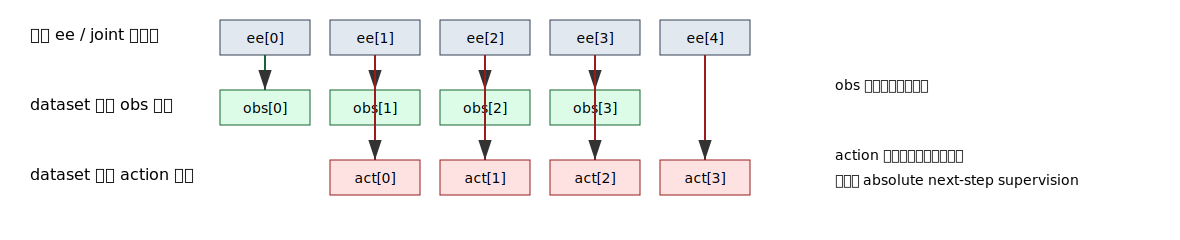


这就是为什么 action 虽然不是 delta pose，但依然能形成序列预测任务。


In [11]:
print_title('可视化: 为什么 dataset 里 obs 和 action 是错开 1 步的')

svg = '''
<svg width='1180' height='240' xmlns='http://www.w3.org/2000/svg'>
  <defs>
    <marker id='arrow2' markerWidth='10' markerHeight='10' refX='9' refY='3' orient='auto'>
      <path d='M0,0 L0,6 L9,3 z' fill='#333' />
    </marker>
  </defs>
  <text x='30' y='40' font-size='16'>原始 ee / joint 时间轴</text>
  <text x='30' y='110' font-size='16'>dataset 中的 obs 序列</text>
  <text x='30' y='180' font-size='16'>dataset 中的 action 序列</text>

  <g font-size='14' text-anchor='middle'>
    <rect x='220' y='20'  width='90' height='35' fill='#e2e8f0' stroke='#334155'/><text x='265' y='43'>ee[0]</text>
    <rect x='330' y='20'  width='90' height='35' fill='#e2e8f0' stroke='#334155'/><text x='375' y='43'>ee[1]</text>
    <rect x='440' y='20'  width='90' height='35' fill='#e2e8f0' stroke='#334155'/><text x='485' y='43'>ee[2]</text>
    <rect x='550' y='20'  width='90' height='35' fill='#e2e8f0' stroke='#334155'/><text x='595' y='43'>ee[3]</text>
    <rect x='660' y='20'  width='90' height='35' fill='#e2e8f0' stroke='#334155'/><text x='705' y='43'>ee[4]</text>

    <rect x='220' y='90'  width='90' height='35' fill='#dcfce7' stroke='#166534'/><text x='265' y='113'>obs[0]</text>
    <rect x='330' y='90'  width='90' height='35' fill='#dcfce7' stroke='#166534'/><text x='375' y='113'>obs[1]</text>
    <rect x='440' y='90'  width='90' height='35' fill='#dcfce7' stroke='#166534'/><text x='485' y='113'>obs[2]</text>
    <rect x='550' y='90'  width='90' height='35' fill='#dcfce7' stroke='#166534'/><text x='595' y='113'>obs[3]</text>

    <rect x='330' y='160' width='90' height='35' fill='#fee2e2' stroke='#991b1b'/><text x='375' y='183'>act[0]</text>
    <rect x='440' y='160' width='90' height='35' fill='#fee2e2' stroke='#991b1b'/><text x='485' y='183'>act[1]</text>
    <rect x='550' y='160' width='90' height='35' fill='#fee2e2' stroke='#991b1b'/><text x='595' y='183'>act[2]</text>
    <rect x='660' y='160' width='90' height='35' fill='#fee2e2' stroke='#991b1b'/><text x='705' y='183'>act[3]</text>
  </g>

  <line x1='265' y1='55' x2='265' y2='90'  stroke='#166534' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='375' y1='55' x2='375' y2='90'  stroke='#166534' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='485' y1='55' x2='485' y2='90'  stroke='#166534' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='595' y1='55' x2='595' y2='90'  stroke='#166534' stroke-width='2' marker-end='url(#arrow2)'/>

  <line x1='375' y1='55' x2='375' y2='160' stroke='#991b1b' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='485' y1='55' x2='485' y2='160' stroke='#991b1b' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='595' y1='55' x2='595' y2='160' stroke='#991b1b' stroke-width='2' marker-end='url(#arrow2)'/>
  <line x1='705' y1='55' x2='705' y2='160' stroke='#991b1b' stroke-width='2' marker-end='url(#arrow2)'/>

  <text x='835' y='90'  font-size='14'>obs 使用当前时刻状态</text>
  <text x='835' y='160' font-size='14'>action 使用下一时刻目标位姿</text>
  <text x='835' y='185' font-size='14'>也就是 absolute next-step supervision</text>
</svg>
'''

maybe_display_svg(svg)

print()
print('这就是为什么 action 虽然不是 delta pose，但依然能形成序列预测任务。')


SequenceSampler: 时间窗是怎么切出来的
真实训练配置中:
- horizon: 16
- n_obs_steps: 2
- n_action_steps: 8
- pad_before: 1
- pad_after: 7

也就是说: 每个样本先切出长度 16 的总时间窗，再只把前 2 步观测喂给 encoder。
玩具例子: episode_length=6, sequence_length=4, pad_before=1, pad_after=2
每一行分别是 [buffer_start_idx, buffer_end_idx, sample_start_idx, sample_end_idx]:
[[0 3 1 4]
 [0 4 0 4]
 [1 5 0 4]
 [2 6 0 4]
 [3 6 0 3]
 [4 6 0 2]]


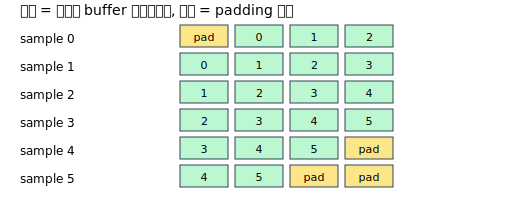


把这个思路放回真实训练里，就是:
  一个 sample 的 action 维度是 [16, 10]
  一个 sample 的 obs 维度只保留前 2 步，所以 image 是 [2, 3, 84, 84]


In [12]:
print_title('SequenceSampler: 时间窗是怎么切出来的')

real_horizon = cfg_so2['horizon']
real_n_obs_steps = cfg_so2['n_obs_steps']
real_n_action_steps = cfg_so2['n_action_steps']
real_pad_before = real_n_obs_steps - 1 + cfg_so2['n_latency_steps']
real_pad_after = real_n_action_steps - 1

print('真实训练配置中:')
print_kv('horizon', real_horizon)
print_kv('n_obs_steps', real_n_obs_steps)
print_kv('n_action_steps', real_n_action_steps)
print_kv('pad_before', real_pad_before)
print_kv('pad_after', real_pad_after)
print()
print('也就是说: 每个样本先切出长度 16 的总时间窗，再只把前 2 步观测喂给 encoder。')

from isp.common.sampler import create_indices

toy_episode_ends = np.array([6], dtype=np.int64)
toy_indices = create_indices(
    episode_ends=toy_episode_ends,
    sequence_length=4,
    episode_mask=np.array([True]),
    pad_before=1,
    pad_after=2,
)

print('玩具例子: episode_length=6, sequence_length=4, pad_before=1, pad_after=2')
print('每一行分别是 [buffer_start_idx, buffer_end_idx, sample_start_idx, sample_end_idx]:')
print(toy_indices)

row_h = 28
base_x = 180
cell_w = 55
svg_rows = []
for ridx, (b0, b1, s0, s1) in enumerate(toy_indices[:6]):
    y = 25 + ridx * row_h
    svg_rows.append(f"<text x='20' y='{y + 18}' font-size='12'>sample {ridx}</text>")
    for t in range(4):
        x = base_x + t * cell_w
        fill = '#fde68a' if (t < s0 or t >= s1) else '#bbf7d0'
        label = 'pad' if (t < s0 or t >= s1) else str(b0 + (t - s0))
        svg_rows.append(f"<rect x='{x}' y='{y}' width='48' height='22' fill='{fill}' stroke='#334155'/>")
        svg_rows.append(f"<text x='{x + 24}' y='{y + 16}' text-anchor='middle' font-size='11'>{label}</text>")

svg = f'''
<svg width='520' height='220' xmlns='http://www.w3.org/2000/svg'>
  <text x='20' y='15' font-size='14'>绿色 = 真正从 buffer 读到的数据, 黄色 = padding 复制</text>
  {''.join(svg_rows)}
</svg>
'''
maybe_display_svg(svg)

print()
print('把这个思路放回真实训练里，就是:')
print('  一个 sample 的 action 维度是 [16, 10]')
print('  一个 sample 的 obs 维度只保留前 2 步，所以 image 是 [2, 3, 84, 84]')

In [13]:
print_title('可选: 真正实例化一个 Dataset，看 __getitem__ 输出什么')

RUN_REAL_DATASET_DEMO = False

if not RUN_REAL_DATASET_DEMO:
    print('默认关闭，因为这会真正解码 demo 图像。')
    print('如果你已经准备好了数据，把 RUN_REAL_DATASET_DEMO 改成 True 后再执行这一格。')
elif AUTO_DATASET_ROOT is None or AUTO_TASK_NAME is None:
    print('无法运行: 自动检测不到 dataset_root 或 task_name。')
else:
    try:
        dataset_cls = import_from_path(cfg_so2['dataset'])
        dataset = dataset_cls(
            shape_meta=task_cfg['shape_meta'],
            dataset_root=str(AUTO_DATASET_ROOT),
            task_name=AUTO_TASK_NAME,
            split='clean',
            n_demo=1,
            horizon=real_horizon,
            pad_before=real_pad_before,
            pad_after=real_pad_after,
            n_obs_steps=real_n_obs_steps,
            abs_action=True,
            use_cache=False,
            use_legacy_normalizer=False,
            normalization_mode='default',
            seed=42,
            val_ratio=0.2,
        )

        sample = dataset[0]
        print_kv('dataset class', type(dataset).__name__)
        print_kv('len(dataset)', len(dataset))
        print_kv('ws_center', dataset.ws_center)
        print()
        print('sample["obs"] 各字段的 shape:')
        rows = []
        for key, value in sample['obs'].items():
            rows.append((key, tuple(value.shape), value.dtype))
        print_table(['obs key', 'shape', 'dtype'], rows)
        print()
        print_kv('sample["action"].shape', tuple(sample['action'].shape))
        print_kv('sample["action"].dtype', sample['action'].dtype)

        normalizer = dataset.get_normalizer()
        print()
        print('normalizer 包含的 key:')
        print(list(normalizer.params_dict.keys()))
    except Exception as exc:
        print('实例化真实 dataset 失败:')
        print(type(exc).__name__, exc)


可选: 真正实例化一个 Dataset，看 __getitem__ 输出什么
默认关闭，因为这会真正解码 demo 图像。
如果你已经准备好了数据，把 RUN_REAL_DATASET_DEMO 改成 True 后再执行这一格。


## 3. 模型主线：从 normalized obs 到 diffusion loss

接下来进入模型本体。最重要的一件事是：

**ISP 不是普通 diffusion policy 最后才加一点 SO2/SO3 修饰。**

它从观测编码、动作表示、群采样到输出层，都是按旋转表示来组织的。

高层主线是：

1. 位置先减 `ws_center`
2. 再用 normalizer 线性缩放
3. `ISPObsEnc` 把图像和机器人状态编码成 SO(3) 特征
4. 把动作轨迹也改写成适合等变处理的表示
5. `EquiGroupSampling` 把连续 SO(3) 特征采样到离散群上
6. `EquiDiffusionUNet` 在离散群的 axis 上做条件 diffusion
7. 用 DDPM 的噪声预测 MSE 训练



SO2 / SO3 真正在哪里分叉
- lmax: 6
- S2 harmonic dim: 49
- SO3 harmonic dim: 455

按代码结构看，SO2 和 SO3 的共享部分是:
  ws_center / normalizer / image -> I2S / robot state lift / diffusion training skeleton

真正分叉的部分主要是:
component             | SO2             | SO3                            
----------------------+-----------------+--------------------------------
dataset normalizer    | xy 对称化, z 单独处理  | xyz 一起对称化                      
group sampling        | C8              | icosahedral group (60 elements)
diffusion output type | 3 个平面向量 + 4 个标量 | 3 个 3D 向量 + 1 个标量              
policy class          | ISPSO2Policy    | ISPSO3Policy                   

动作在内部的几何语义重组是:
  SO3: [xyz 向量] + [rot col1 向量] + [rot col2 向量] + [gripper 标量]
  SO2: [xy 向量] + [z 标量] + [rot1_xy 向量] + [rot1_z 标量] + [rot2_xy 向量] + [rot2_z 标量] + [gripper 标量]

一个非常值得注意的代码细节:
  equi_obs_encoder_so2.py 里有一条注释写着 enc_128_out -> 49，这条注释已经陈旧。
  因为 I2SPolicy 的输出是 SO(3) irreps，在 lmax=6 时维度应是 455。


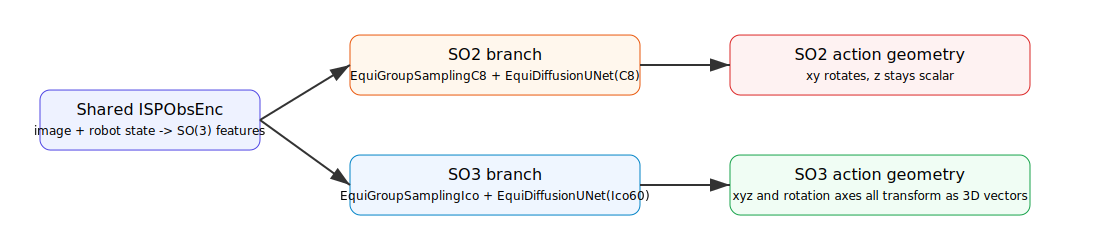

In [14]:
print_title('SO2 / SO3 真正在哪里分叉')

def s2_irrep_dim(lmax):
    return sum(2 * l + 1 for l in range(lmax + 1))


def so3_irrep_dim(lmax):
    return sum((2 * l + 1) ** 2 for l in range(lmax + 1))


lmax = cfg_so2['policy']['lmax']
print_kv('lmax', lmax)
print_kv('S2 harmonic dim', s2_irrep_dim(lmax))
print_kv('SO3 harmonic dim', so3_irrep_dim(lmax))
print()
print('按代码结构看，SO2 和 SO3 的共享部分是:')
print('  ws_center / normalizer / image -> I2S / robot state lift / diffusion training skeleton')
print()
print('真正分叉的部分主要是:')
rows = [
    ('dataset normalizer', 'xy 对称化, z 单独处理', 'xyz 一起对称化'),
    ('group sampling', 'C8', 'icosahedral group (60 elements)'),
    ('diffusion output type', '3 个平面向量 + 4 个标量', '3 个 3D 向量 + 1 个标量'),
    ('policy class', 'ISPSO2Policy', 'ISPSO3Policy'),
]
print_table(['component', 'SO2', 'SO3'], rows)

print()
print('动作在内部的几何语义重组是:')
print('  SO3: [xyz 向量] + [rot col1 向量] + [rot col2 向量] + [gripper 标量]')
print('  SO2: [xy 向量] + [z 标量] + [rot1_xy 向量] + [rot1_z 标量] + [rot2_xy 向量] + [rot2_z 标量] + [gripper 标量]')

print()
print('一个非常值得注意的代码细节:')
print('  equi_obs_encoder_so2.py 里有一条注释写着 enc_128_out -> 49，这条注释已经陈旧。')
print('  因为 I2SPolicy 的输出是 SO(3) irreps，在 lmax=6 时维度应是 455。')

svg = '''
<svg width='1100' height='250' xmlns='http://www.w3.org/2000/svg'>
  <defs>
    <marker id='arrow3' markerWidth='10' markerHeight='10' refX='9' refY='3' orient='auto'>
      <path d='M0,0 L0,6 L9,3 z' fill='#333' />
    </marker>
  </defs>
  <rect x='40' y='90' width='220' height='60' rx='10' fill='#eef2ff' stroke='#4f46e5'/>
  <text x='150' y='115' text-anchor='middle' font-size='16'>Shared ISPObsEnc</text>
  <text x='150' y='135' text-anchor='middle' font-size='12'>image + robot state -> SO(3) features</text>

  <rect x='350' y='35' width='290' height='60' rx='10' fill='#fff7ed' stroke='#ea580c'/>
  <text x='495' y='60' text-anchor='middle' font-size='16'>SO2 branch</text>
  <text x='495' y='80' text-anchor='middle' font-size='12'>EquiGroupSamplingC8 + EquiDiffusionUNet(C8)</text>

  <rect x='350' y='155' width='290' height='60' rx='10' fill='#eff6ff' stroke='#0284c7'/>
  <text x='495' y='180' text-anchor='middle' font-size='16'>SO3 branch</text>
  <text x='495' y='200' text-anchor='middle' font-size='12'>EquiGroupSamplingIco + EquiDiffusionUNet(Ico60)</text>

  <rect x='730' y='35' width='300' height='60' rx='10' fill='#fef2f2' stroke='#dc2626'/>
  <text x='880' y='60' text-anchor='middle' font-size='16'>SO2 action geometry</text>
  <text x='880' y='80' text-anchor='middle' font-size='12'>xy rotates, z stays scalar</text>

  <rect x='730' y='155' width='300' height='60' rx='10' fill='#f0fdf4' stroke='#16a34a'/>
  <text x='880' y='180' text-anchor='middle' font-size='16'>SO3 action geometry</text>
  <text x='880' y='200' text-anchor='middle' font-size='12'>xyz and rotation axes all transform as 3D vectors</text>

  <line x1='260' y1='120' x2='350' y2='65'  stroke='#333' stroke-width='2' marker-end='url(#arrow3)'/>
  <line x1='260' y1='120' x2='350' y2='185' stroke='#333' stroke-width='2' marker-end='url(#arrow3)'/>
  <line x1='640' y1='65'  x2='730' y2='65'  stroke='#333' stroke-width='2' marker-end='url(#arrow3)'/>
  <line x1='640' y1='185' x2='730' y2='185' stroke='#333' stroke-width='2' marker-end='url(#arrow3)'/>
</svg>
'''

maybe_display_svg(svg)

In [15]:
print_title('可选: 用随机张量做一次干跑，观察 encoder / sampler / diffusion 的 shape')

RUN_DRY_MODEL_DEMO = False

if not RUN_DRY_MODEL_DEMO:
    print('默认关闭，因为 escnn / e3nn / diffusers / pytorch3d 这些依赖比较重。')
    print('如果你的环境已经装好 ISP 训练依赖，把 RUN_DRY_MODEL_DEMO 改成 True 再执行。')
else:
    try:
        import torch
        from diffusers.schedulers.scheduling_ddpm import DDPMScheduler
        from isp.policy.isp_so2_policy import ISPSO2Policy
        from isp.policy.isp_so3_policy import ISPSO3Policy

        def build_policy(raw_cfg, policy_cls):
            sch_cfg = dict(raw_cfg['noise_scheduler'])
            sch_cfg.pop('_target_', None)
            scheduler = DDPMScheduler(**sch_cfg)
            return policy_cls(
                shape_meta=task_cfg['shape_meta'],
                noise_scheduler=scheduler,
                horizon=cfg_so2['horizon'],
                n_action_steps=cfg_so2['n_action_steps'],
                n_obs_steps=cfg_so2['n_obs_steps'],
                num_inference_steps=raw_cfg['num_inference_steps'],
                crop_shape=raw_cfg['crop_shape'],
                diffusion_step_embed_dim=raw_cfg['diffusion_step_embed_dim'],
                enc_n_hidden=raw_cfg['enc_n_hidden'],
                down_dims=tuple(raw_cfg['down_dims']),
                kernel_size=raw_cfg['kernel_size'],
                n_groups=raw_cfg['n_groups'],
                cond_predict_scale=raw_cfg['cond_predict_scale'],
                rot_aug=raw_cfg['rot_aug'],
                lmax=raw_cfg['lmax'],
                s2_fdim=raw_cfg['s2_fdim'],
                so3_fdim=raw_cfg['so3_fdim'],
                initialize=raw_cfg['initialize'],
                encoder=raw_cfg['encoder'],
            )

        so2_policy = build_policy(cfg_so2['policy'], ISPSO2Policy)
        so3_policy = build_policy(cfg_so3['policy'], ISPSO3Policy)

        B = 1
        To = cfg_so2['n_obs_steps']
        T = cfg_so2['horizon']
        dummy_obs = {
            'robot0_eye_in_hand_image': torch.randn(B, To, 3, 84, 84),
            'robot0_eef_pos': torch.randn(B, To, 3) * 0.1,
            'robot0_eef_quat': torch.tensor([[[1.0, 0.0, 0.0, 0.0]]]).repeat(B, To, 1),
            'robot0_gripper_qpos': torch.zeros(B, To, 2),
        }
        dummy_traj = torch.randn(B, T, 10)

        for name, policy in [('SO2', so2_policy), ('SO3', so3_policy)]:
            print()
            print('=' * 40, name, '=' * 40)
            with torch.no_grad():
                global_cond = policy.enc(dummy_obs)
                sampled = policy.equi_sampler(global_cond, dummy_traj)
                pred = policy.diff(
                    sampled['trajectory'],
                    timestep=torch.tensor([0]),
                    local_cond=None,
                    global_cond=sampled['global_cond'],
                )
            print_kv('global_cond shape', tuple(global_cond.shape))
            print_kv('sampled trajectory shape', tuple(sampled['trajectory'].shape))
            print_kv('sampled global_cond shape', tuple(sampled['global_cond'].shape))
            print_kv('diffusion output shape', tuple(pred.shape))
    except Exception as exc:
        print('干跑失败:')
        print(type(exc).__name__, exc)


可选: 用随机张量做一次干跑，观察 encoder / sampler / diffusion 的 shape
默认关闭，因为 escnn / e3nn / diffusers / pytorch3d 这些依赖比较重。
如果你的环境已经装好 ISP 训练依赖，把 RUN_DRY_MODEL_DEMO 改成 True 再执行。



训练 loop 每个 epoch 到底发生什么
1. DataLoader 取出一个 batch: obs 前 2 步, action 全 16 步
2. batch 搬到 GPU
3. model.compute_loss(batch)
4. backward + AdamW.step + lr_scheduler.step
5. 如果开启 EMA, 就更新 ema_model
6. epoch 末计算 val_loss
7. 用一个固定 train batch 做 predict_action, 记录 train_action_mse_error
8. 保存 latest checkpoint, 同时按 val_loss 维护 top-k checkpoint
9. wandb 和 logs.json.txt 记录指标

SO2 默认训练节奏:
field            | value 
-----------------+-------
batch_size       | 64    
num_epochs       | 200   
val_every        | 1     
sample_every     | 5     
checkpoint_every | 10.0  
use_ema          | 1     
lr_scheduler     | cosine

一个特别值得注意的代码细节:
  val_loss 用的是 self.model.compute_loss(batch)
  但 sample / predict_action 时用的是 ema_model (如果 use_ema=True)
也就是说: 验证损失监控的是在线模型, 采样质量演示看的是 EMA 模型。


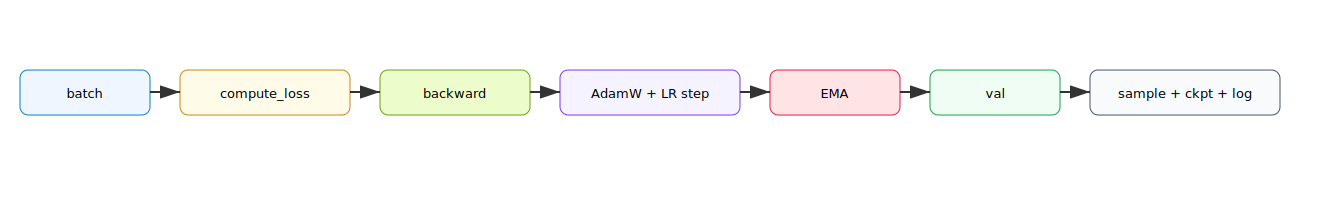

In [16]:
print_title('训练 loop 每个 epoch 到底发生什么')

checkpoint_every = 1000 / cfg_so2['n_demo']

steps = [
    '1. DataLoader 取出一个 batch: obs 前 2 步, action 全 16 步',
    '2. batch 搬到 GPU',
    '3. model.compute_loss(batch)',
    '4. backward + AdamW.step + lr_scheduler.step',
    '5. 如果开启 EMA, 就更新 ema_model',
    '6. epoch 末计算 val_loss',
    '7. 用一个固定 train batch 做 predict_action, 记录 train_action_mse_error',
    '8. 保存 latest checkpoint, 同时按 val_loss 维护 top-k checkpoint',
    '9. wandb 和 logs.json.txt 记录指标',
]

for s in steps:
    print(s)

print()
print('SO2 默认训练节奏:')
rows = [
    ('batch_size', cfg_so2['dataloader']['batch_size']),
    ('num_epochs', cfg_so2['training']['num_epochs']),
    ('val_every', cfg_so2['training']['val_every']),
    ('sample_every', cfg_so2['training']['sample_every']),
    ('checkpoint_every', checkpoint_every),
    ('use_ema', cfg_so2['training']['use_ema']),
    ('lr_scheduler', cfg_so2['training']['lr_scheduler']),
]
print_table(['field', 'value'], rows)

print()
print('一个特别值得注意的代码细节:')
print('  val_loss 用的是 self.model.compute_loss(batch)')
print('  但 sample / predict_action 时用的是 ema_model (如果 use_ema=True)')
print('也就是说: 验证损失监控的是在线模型, 采样质量演示看的是 EMA 模型。')

svg = '''
<svg width='1320' height='200' xmlns='http://www.w3.org/2000/svg'>
  <defs>
    <marker id='arrow4' markerWidth='10' markerHeight='10' refX='9' refY='3' orient='auto'>
      <path d='M0,0 L0,6 L9,3 z' fill='#333' />
    </marker>
  </defs>
  <g font-size='13' text-anchor='middle'>
    <rect x='20'  y='70' width='130' height='45' rx='8' fill='#eff6ff' stroke='#0284c7'/><text x='85'  y='98'>batch</text>
    <rect x='180' y='70' width='170' height='45' rx='8' fill='#fefce8' stroke='#ca8a04'/><text x='265' y='98'>compute_loss</text>
    <rect x='380' y='70' width='150' height='45' rx='8' fill='#ecfccb' stroke='#65a30d'/><text x='455' y='98'>backward</text>
    <rect x='560' y='70' width='180' height='45' rx='8' fill='#f5f3ff' stroke='#7c3aed'/><text x='650' y='98'>AdamW + LR step</text>
    <rect x='770' y='70' width='130' height='45' rx='8' fill='#ffe4e6' stroke='#e11d48'/><text x='835' y='98'>EMA</text>
    <rect x='930' y='70' width='130' height='45' rx='8' fill='#f0fdf4' stroke='#16a34a'/><text x='995' y='98'>val</text>
    <rect x='1090' y='70' width='190' height='45' rx='8' fill='#f8fafc' stroke='#475569'/><text x='1185' y='98'>sample + ckpt + log</text>
  </g>
  <line x1='150' y1='92' x2='180' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
  <line x1='350' y1='92' x2='380' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
  <line x1='530' y1='92' x2='560' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
  <line x1='740' y1='92' x2='770' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
  <line x1='900' y1='92' x2='930' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
  <line x1='1060' y1='92' x2='1090' y2='92' stroke='#333' stroke-width='2' marker-end='url(#arrow4)'/>
</svg>
'''

maybe_display_svg(svg)

## 4. 读完这份 notebook 后，你应该能回答什么

如果这份 notebook 的主线已经吃住了，你应该已经能清楚回答下面这些问题：

- 为什么 dataset 里 action 是 `ee[1:]` 而 obs 是 `ee[:-1]`
- 为什么一个 sample 的 action 长度是 `16`，但实际执行只取其中 `8` 步
- `ws_center` 为什么要先减掉
- `rotation_6d` 为什么会在内部改写成两根旋转轴
- `SO2` 和 `SO3` 的主要区别为什么不是“读不同数据”，而是“怎样组织表示与群采样”
- 为什么 ISP 里真正的条件来自 observation encoder，而不是 trajectory mask

如果你愿意，后面可以继续写第二份 notebook，专门只讲一个主题，例如：

1. `compute_loss()` 逐行拆解
2. `I2SPolicy` 中 `image -> S2 -> SO3` 的数学与代码对应
3. `SO2` 和 `SO3` 输出层为什么要按那种方式拆 action
4. `TrainISPWorkspace` 中 validation / EMA / checkpoint 的细节和潜在坑
